Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading data...

Training ImprovedFuzzySoft...

Training LDA...

Training SVM...

Training RandomForest...

Training NaiveBayes...

PERFORMANCE COMPARISON
                   Accuracy  Precision  Recall  F1-Score  Specificity     AUC
ImprovedFuzzySoft     0.940     0.9615  0.9722    0.9669         0.65  0.7525
LDA                   0.965     0.9676  0.9944    0.9808         0.70  0.9853
SVM                   0.965     0.9626  1.0000    0.9809         0.65  0.9883
RandomForest          0.965     0.9676  0.9944    0.9808         0.70  0.9818
NaiveBayes            0.830     0.9932  0.8167    0.8963         0.95  0.9558


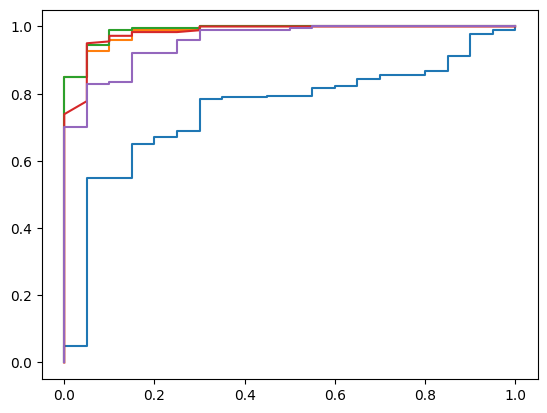

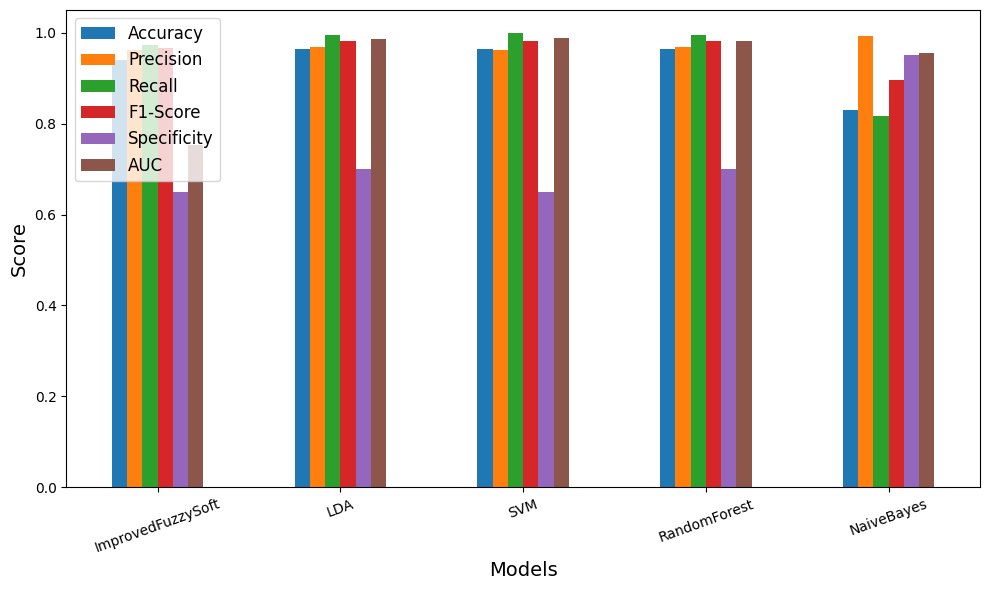


5-FOLD CROSS VALIDATION
ImprovedFuzzySoft    : 0.9370 ± 0.0075
LDA                  : 0.9580 ± 0.0140
SVM                  : 0.9670 ± 0.0103
RandomForest         : 0.9690 ± 0.0080
NaiveBayes           : 0.8170 ± 0.0144

📊 Combined Confusion Tables

ImprovedFuzzySoft Confusion Matrix:
[[ 13   7]
 [  5 175]]

LDA Confusion Matrix:
[[ 14   6]
 [  1 179]]

SVM Confusion Matrix:
[[ 13   7]
 [  0 180]]

RandomForest Confusion Matrix:
[[ 14   6]
 [  1 179]]

NaiveBayes Confusion Matrix:
[[ 19   1]
 [ 33 147]]


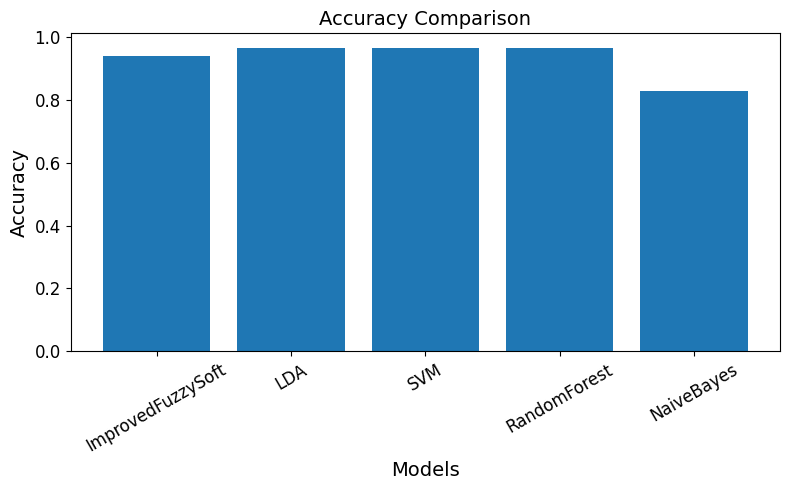

/tmp/ipykernel_5688/1017272993.py:395: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(


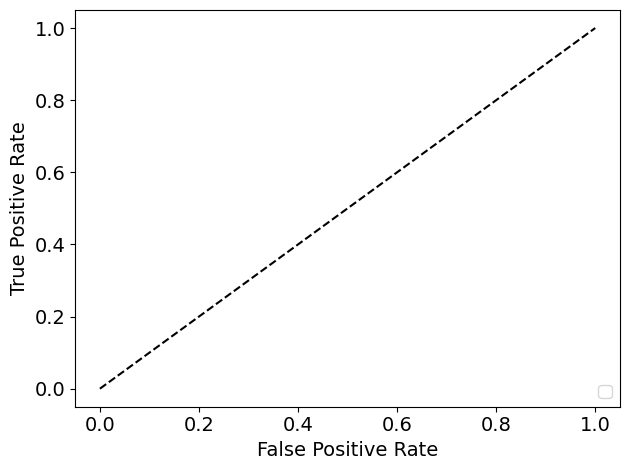

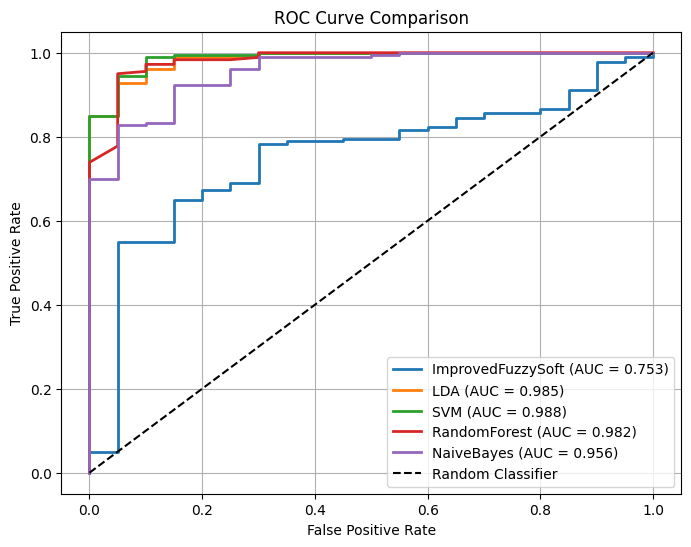


Ablation Study
Without Weights: 0.98
With Weights: {'Accuracy': 0.94, 'Precision': 0.9615384615384616, 'Recall': 0.9722222222222222, 'F1-Score': 0.9668508287292817, 'Specificity': np.float64(0.649999999675), 'AUC': np.float64(0.7525000000000001)}

INTERPRETABILITY ANALYSIS

Feature Importance Ranking
            Feature    Weight
9  GLCM_Correlation  0.450523
6     GLCM_Contrast  0.307426
4             HSV_S  0.151625
3             HSV_H  0.044738
8  GLCM_Homogeneity  0.035839
2             RGB_B  0.006487
0             RGB_R  0.001185
7       GLCM_Energy  0.001171
5             HSV_V  0.000887
1             RGB_G  0.000118

Top 5 Most Important Features
            Feature    Weight
9  GLCM_Correlation  0.450523
6     GLCM_Contrast  0.307426
4             HSV_S  0.151625
3             HSV_H  0.044738
8  GLCM_Homogeneity  0.035839


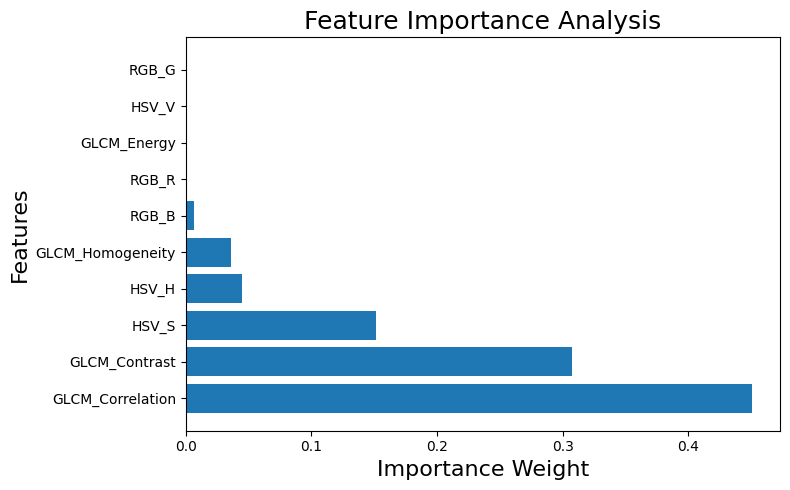

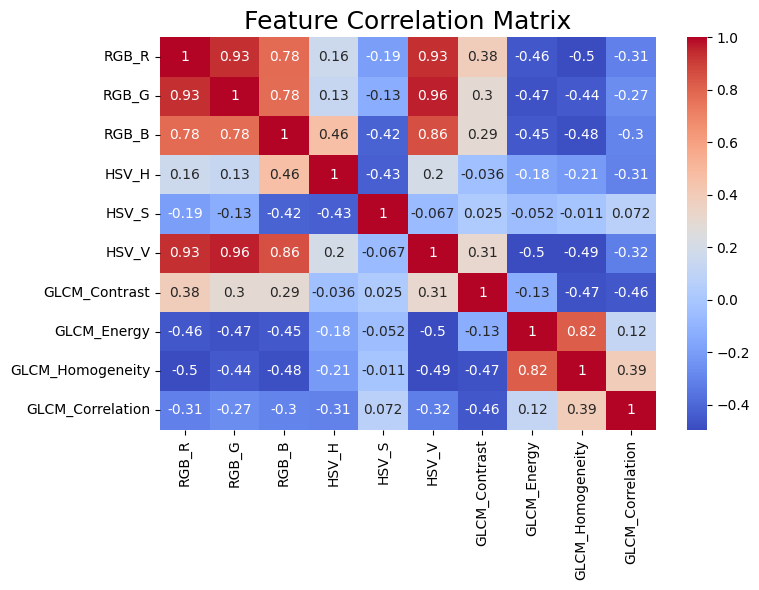

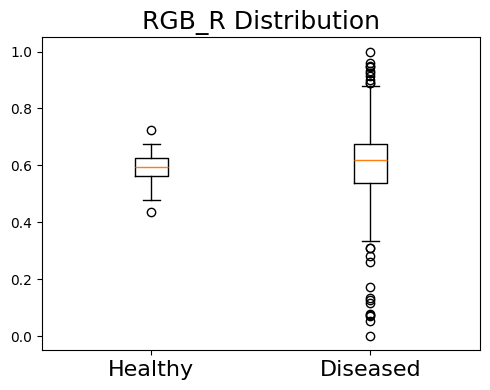

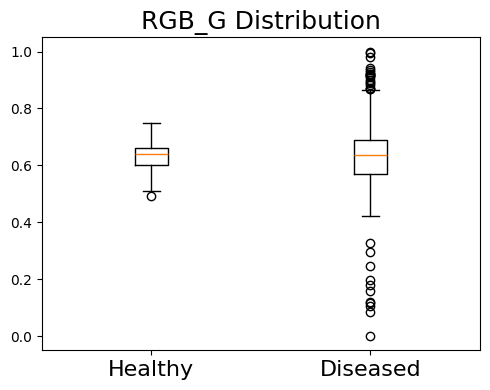

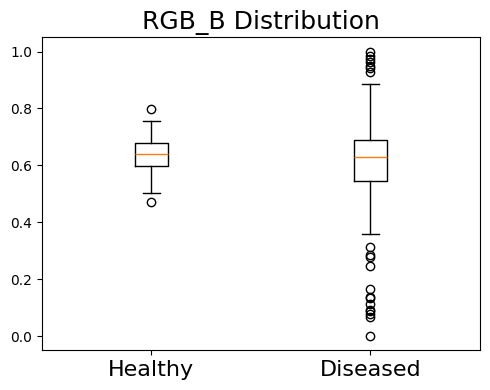

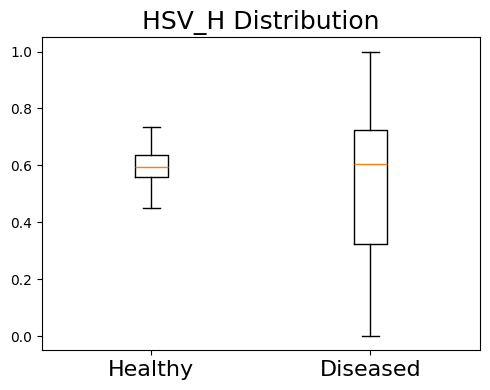

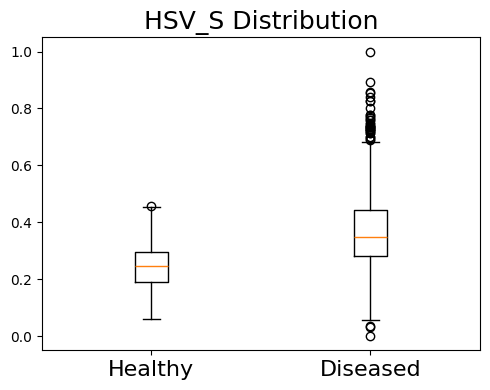

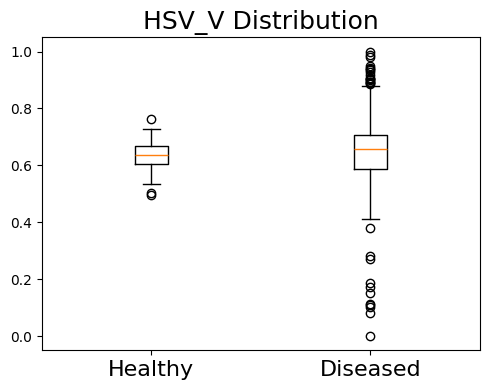

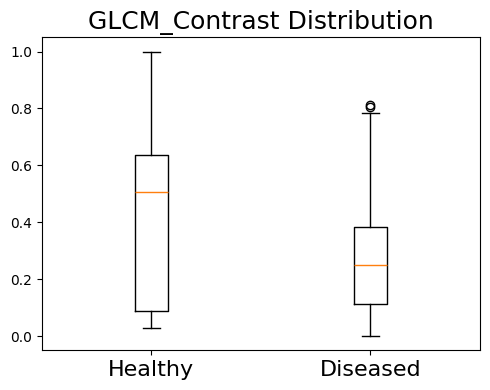

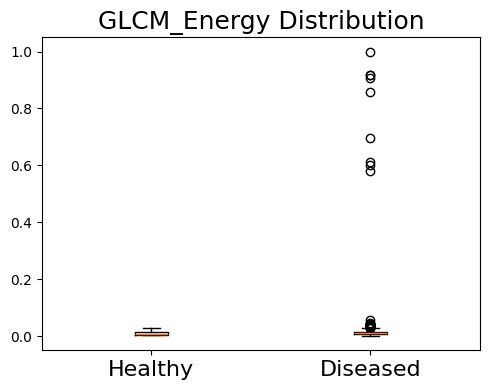

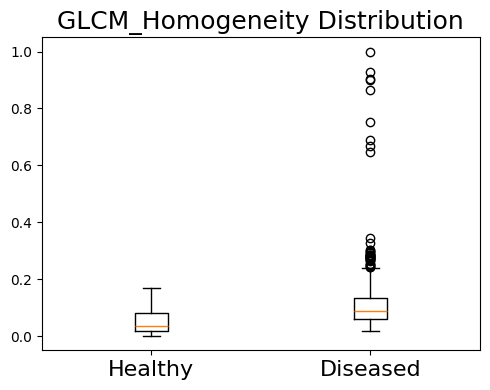

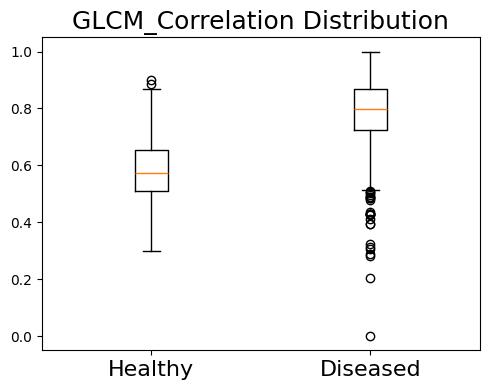


Prototype Analysis

Class 0 Prototypes
      RGB_R     RGB_G     RGB_B     HSV_H     HSV_S     HSV_V  GLCM_Contrast  \
0  0.000741  0.000077  0.004404  0.027110  0.039544  0.000591       0.164173   
1  0.000650  0.000074  0.003893  0.026571  0.027412  0.000540       0.021045   
2  0.000694  0.000071  0.003998  0.025322  0.048481  0.000544       0.233521   

   GLCM_Energy  GLCM_Homogeneity  GLCM_Correlation  
0     0.000007          0.000813          0.221273  
1     0.000022          0.003945          0.314492  
2     0.000008          0.001092          0.253886  

Class 1 Prototypes
      RGB_R     RGB_G     RGB_B     HSV_H     HSV_S     HSV_V  GLCM_Contrast  \
0  0.000781  0.000079  0.004271  0.022843  0.055935  0.000613       0.130759   
1  0.000654  0.000070  0.003739  0.022647  0.056713  0.000536       0.039727   
2  0.000765  0.000078  0.004197  0.029491  0.060566  0.000612       0.072018   

   GLCM_Energy  GLCM_Homogeneity  GLCM_Correlation  
0     0.000012          0.002545 

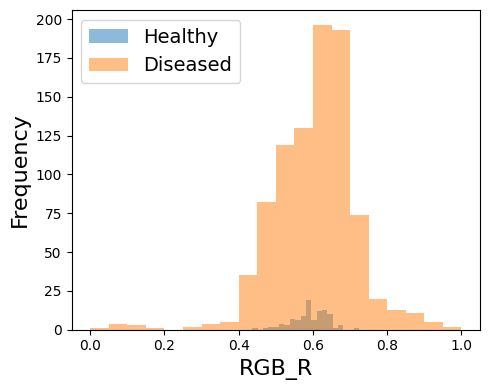

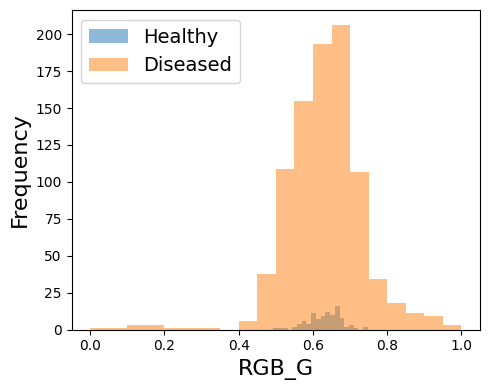

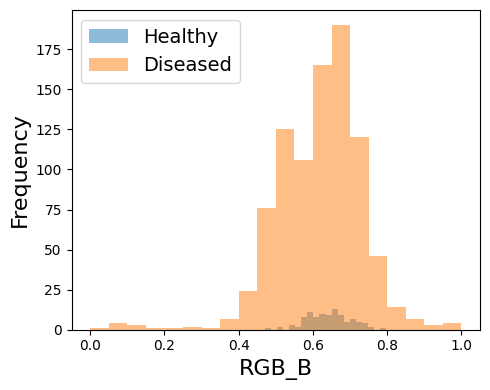

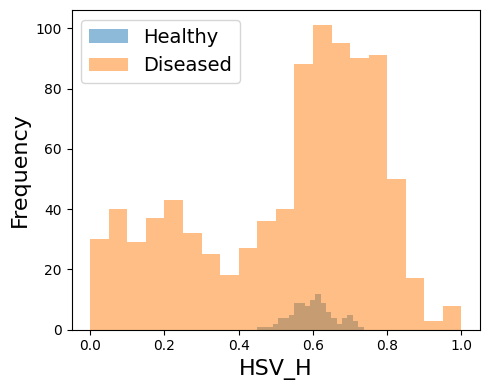

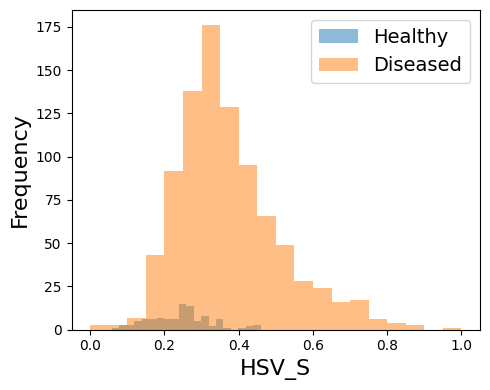

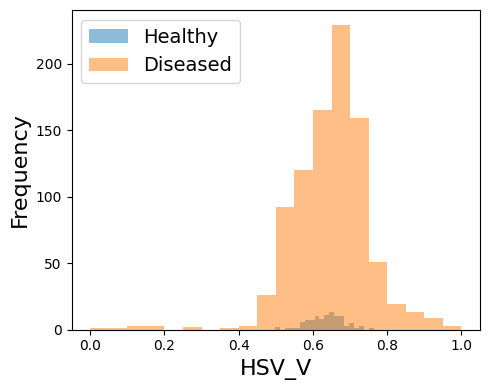

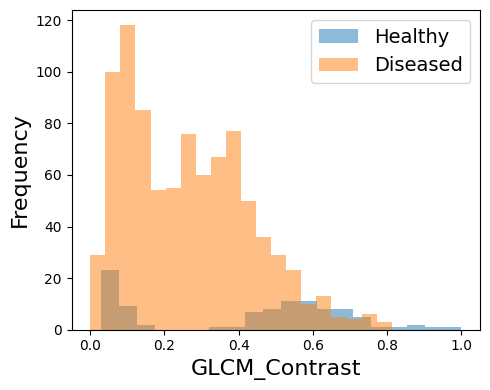

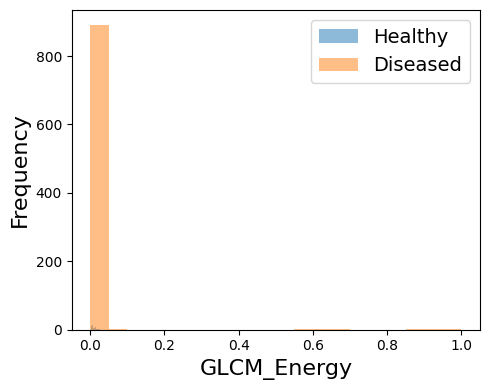

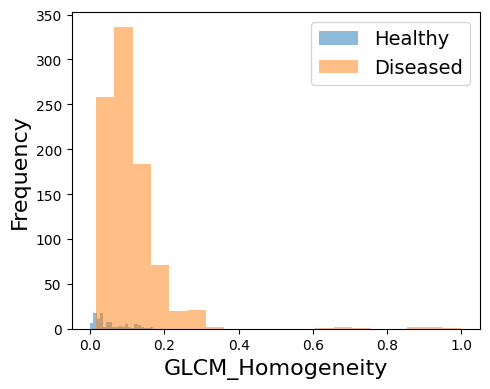

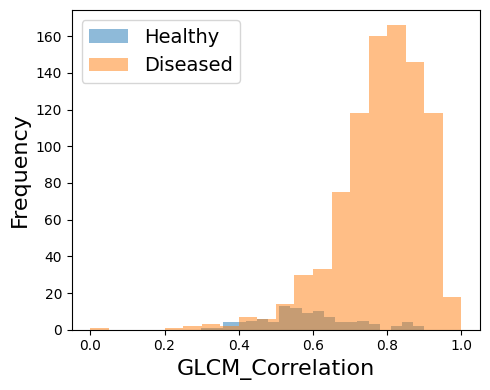


Wilcoxon Test (Fuzzy vs RandomForest)
Statistic: 18.0
p-value: 0.13166801602281422


In [5]:
# ==========================================
# FULL ENHANCED PIPELINE (ORIGINAL + ADDED ANALYSIS)
# ==========================================

import os
import numpy as np
import random
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from PIL import Image
from tqdm import tqdm

from skimage.feature import graycomatrix, graycoprops
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    confusion_matrix
)

from sklearn.cluster import KMeans
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from statsmodels.stats.contingency_tables import mcnemar
from scipy.stats import wilcoxon
from sklearn.model_selection import StratifiedKFold
# ==============================
# SEED
# ==============================
SEED = 42

random.seed(SEED)
np.random.seed(SEED)


from google.colab import drive
drive.mount('/content/drive')
# ==============================
# CONFIG
# ==============================
DATASET_PATH = "/content/drive/MyDrive/PlantVillageDataset"
IMG_SIZE = (128, 128)
MAX_IMAGES_PER_CLASS = 100
# ==============================
# FEATURE NAMES
# ==============================
feature_names = [
    "RGB_R",
    "RGB_G",
    "RGB_B",
    "HSV_H",
    "HSV_S",
    "HSV_V",
    "GLCM_Contrast",
    "GLCM_Energy",
    "GLCM_Homogeneity",
    "GLCM_Correlation"
]
# ==============================
# IMAGE + FEATURES
# ==============================
def preprocess_image(path):
    img = Image.open(path).convert("RGB")
    img = img.resize(IMG_SIZE)
    return np.array(img)

def extract_features(img):

    rgb = np.mean(img, axis=(0, 1))

    hsv = np.array(Image.fromarray(img).convert("HSV"))
    hsv = np.mean(hsv, axis=(0, 1))

    gray = np.dot(img[..., :3], [0.299, 0.587, 0.114]).astype(np.uint8)

    glcm = graycomatrix(gray, [1,2], [0, np.pi/4, np.pi/2],
                        symmetric=True, normed=True)

    texture = [
        graycoprops(glcm, 'contrast').mean(),
        graycoprops(glcm, 'energy').mean(),
        graycoprops(glcm, 'homogeneity').mean(),
        graycoprops(glcm, 'correlation').mean()
    ]

    return np.concatenate([rgb, hsv, texture])

# ==============================
# NORMALIZATION
# ==============================
def normalize(X):
    X = np.nan_to_num(X)
    return (X - X.min(0)) / (X.max(0) - X.min(0) + 1e-8)

# ==============================
# LOAD DATASET (BINARY)
# ==============================
def load_dataset():
    X, y = [], []

    for cls in os.listdir(DATASET_PATH):

        if "Tomato" not in cls:
            continue

        label = 0 if "healthy" in cls.lower() else 1
        folder = os.path.join(DATASET_PATH, cls)

        for img_name in os.listdir(folder)[:MAX_IMAGES_PER_CLASS]:
            try:
                img = preprocess_image(os.path.join(folder, img_name))
                feat = extract_features(img)

                X.append(feat)
                y.append(label)
            except:
                continue

    return np.array(X), np.array(y)

# ==============================
# IMPROVED FUZZY SOFT MODEL
# ==============================
class ImprovedFuzzySoft:

    def fit(self, X, y):
        self.classes = np.unique(y)
        self.prototypes = {}
        self.cov_inv = {}
        self.sigmas = {}

        self.weights = self.compute_weights(X, y)
        Xw = X * self.weights

        for cls in self.classes:
            data = Xw[y == cls]

            km = KMeans(n_clusters=3, random_state=SEED).fit(data)
            self.prototypes[cls] = km.cluster_centers_

            cov = np.cov(data.T) + np.eye(data.shape[1]) * 1e-5
            self.cov_inv[cls] = np.linalg.inv(cov)

            self.sigmas[cls] = np.std(data) + 1e-6

    def compute_weights(self, X, y):
        weights = []
        for i in range(X.shape[1]):
            f = X[:, i]
            means = [np.mean(f[y == c]) for c in np.unique(y)]
            weights.append(np.var(means))
        w = np.array(weights)
        return w / (np.sum(w) + 1e-8)

    def mahalanobis(self, x, mean, cov_inv):
        diff = x - mean
        return np.sqrt(diff @ cov_inv @ diff.T)

    def similarity(self, x, cls):
        sims = []

        for c in self.prototypes[cls]:
            dist = self.mahalanobis(x, c, self.cov_inv[cls])
            sigma = self.sigmas[cls]
            sims.append(np.exp(-(dist**2) / (2 * sigma**2)))

        sims = sorted(sims, reverse=True)[:2]
        return np.mean(sims)

    def predict_proba(self, X):
        Xw = X * self.weights
        probs = []

        for x in Xw:
            scores = [self.similarity(x, c) for c in self.classes]
            scores = np.array(scores)
            probs.append(scores / (np.sum(scores) + 1e-8))

        return np.array(probs)

    def predict(self, X):
        probs = self.predict_proba(X)
        return np.argmax(probs, axis=1)

# ==============================
# CROSS VALIDATION
# ==============================
from sklearn.model_selection import StratifiedKFold
def cross_validate_model(model, X, y, folds=5):

    skf = StratifiedKFold(
        n_splits=folds,
        shuffle=True,
        random_state=SEED
    )

    scores = []

    for train_idx, test_idx in skf.split(X, y):

        X_train_cv = X[train_idx]
        X_test_cv = X[test_idx]

        y_train_cv = y[train_idx]
        y_test_cv = y[test_idx]

        model.fit(X_train_cv, y_train_cv)

        y_pred_cv = model.predict(X_test_cv)

        acc = accuracy_score(
            y_test_cv,
            y_pred_cv
        )

        scores.append(acc)

    return np.array(scores)
# ==============================
# MAIN
# ==============================
if __name__ == "__main__":

    print("Loading data...")
    X, y = load_dataset()

    X = normalize(X)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=y
    )

    models = {
        "ImprovedFuzzySoft": ImprovedFuzzySoft(),
        "LDA": LinearDiscriminantAnalysis(),
        "SVM": SVC(probability=True),
        "RandomForest": RandomForestClassifier(),
        "NaiveBayes": GaussianNB()
    }

    results = {}
    predictions = {}
    conf_tables = {}
    roc_data = {}

    plt.figure()

    for name, model in models.items():

        print(f"\nTraining {name}...")

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

        predictions[name] = y_pred

        acc = accuracy_score(y_test, y_pred)

        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)

        cm = confusion_matrix(y_test, y_pred)

        tn, fp, fn, tp = cm.ravel()

        specificity = tn / (tn + fp + 1e-8)

        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)

        roc_data[name] = (fpr, tpr, roc_auc)

        results[name] = {
            "Accuracy": acc,
            "Precision": precision,
            "Recall": recall,
            "F1-Score": f1,
            "Specificity": specificity,
            "AUC": roc_auc
        }

        plt.plot(
            fpr,
            tpr,
            label=f"{name} (AUC={roc_auc:.3f})"
        )

        conf_tables[name] = cm

    print("\n================================================")
    print("PERFORMANCE COMPARISON")
    print("================================================")

    results_df = pd.DataFrame(results).T

    results_df = results_df.round(4)

    print(results_df)
    results_df.plot(
        kind='bar',
        figsize=(10,6)
    )

    plt.ylabel("Score", fontsize=14)
    plt.xlabel("Models", fontsize=14)

    plt.xticks(rotation=20)
    plt.legend(fontsize=12)

    plt.tight_layout()
    plt.show()

    print("\n================================================")
    print("5-FOLD CROSS VALIDATION")
    print("================================================")

    cv_results = {}

    for name, model in models.items():

        scores = cross_validate_model(model,X,y,folds=5)

        cv_results[name] = scores

        print(
            f"{name:20s} : "
            f"{scores.mean():.4f} ± {scores.std():.4f}"
        )

    # ==========================
    # SINGLE CONFUSION TABLE
    # ==========================
    print("\n📊 Combined Confusion Tables")
    for k, cm in conf_tables.items():
        print(f"\n{k} Confusion Matrix:")
        print(cm)
    # ==========================
    # Accuracy Histogram
    # ==========================
    plt.figure(figsize=(8,5))

    model_names = list(results.keys())
    accuracies = [results[m]["Accuracy"] for m in model_names]

    plt.bar(model_names, accuracies)

    plt.ylabel("Accuracy", fontsize=14)
    plt.xlabel("Models", fontsize=14)

    plt.xticks(rotation=30, fontsize=12)
    plt.yticks(fontsize=12)

    plt.title("Accuracy Comparison", fontsize=14)

    plt.tight_layout()
    plt.show()

    # ==========================
    # ROC CURVE
    # ==========================
    # Random classifier line
    plt.plot(
        [0,1],
        [0,1],
        'k--',
        linewidth=1.5
    )

    # Axis labels
    plt.xlabel(
        'False Positive Rate',
        fontsize=14
    )

    plt.ylabel(
        'True Positive Rate',
        fontsize=14
    )

    # Tick labels
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)

    # Legend
    plt.legend(
        loc='lower right',
        fontsize=12,
        frameon=True
    )

    plt.tight_layout()

    plt.savefig(
        'ROC_Curve.tif',
        dpi=600,
        bbox_inches='tight'
    )

    plt.show()

    # ==========================
    # ROC CURVE
    # ==========================

    plt.figure(figsize=(8,6))

    for name, (fpr, tpr, roc_auc) in roc_data.items():

        plt.plot(
            fpr,
            tpr,
            linewidth=2,
            label=f'{name} (AUC = {roc_auc:.3f})'
        )

    plt.plot([0,1],[0,1],'k--', label='Random Classifier')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve Comparison")
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

    # ==========================
    # ABLATION STUDY
    # ==========================
    print("\nAblation Study")
    fs_no_weight = ImprovedFuzzySoft()
    fs_no_weight.compute_weights = lambda X,y: np.ones(X.shape[1])

    fs_no_weight.fit(X_train, y_train)
    y_pred_ab = fs_no_weight.predict(X_test)
    acc_ab = accuracy_score(y_test, y_pred_ab)

    print("Without Weights:", acc_ab)
    print("With Weights:", results["ImprovedFuzzySoft"])

    # ==========================
    # INTERPRETABILITY ANALYSIS
    # ==========================

    print("\n================================================")
    print("INTERPRETABILITY ANALYSIS")
    print("================================================")

    fuzzy_model = models["ImprovedFuzzySoft"]

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Weight": fuzzy_model.weights
    })

    importance_df = importance_df.sort_values(
        by="Weight",
        ascending=False
    )

    print("\nFeature Importance Ranking")
    print(importance_df)
    print("\nTop 5 Most Important Features")

    print(
        importance_df.head(5)
    )
    # Feature Importance Plot

    plt.figure(figsize=(8,5))

    plt.barh(
        importance_df["Feature"],
        importance_df["Weight"]
    )

    plt.xlabel("Importance Weight",fontsize=16)
    plt.ylabel("Features",fontsize=16)
    plt.title("Feature Importance Analysis",fontsize=18)

    plt.tight_layout()
    plt.show()

    # ==========================
    # FEATURE CORRELATION
    # ==========================

    feature_df = pd.DataFrame(
        X,
        columns=feature_names
    )

    plt.figure(figsize=(8,6))

    sns.heatmap(
        feature_df.corr(),
        annot=True,
        cmap='coolwarm'
    )

    plt.title(
        "Feature Correlation Matrix",
        fontsize=18
    )

    plt.tight_layout()
    plt.show()

    # ==========================
    # CLASS-WISE DISTRIBUTION
    # ==========================

    for i, feature in enumerate(feature_names):

        plt.figure(figsize=(5,4))

        plt.boxplot([
            X[y == 0][:, i],
            X[y == 1][:, i]
        ])

        plt.xticks(
            [1,2],
            ["Healthy", "Diseased"],
            fontsize=16
        )

        plt.title(
            f"{feature} Distribution",
            fontsize=18
        )

        plt.tight_layout()
        plt.show()

    # ==========================
    # PROTOTYPE ANALYSIS
    # ==========================

    print("\nPrototype Analysis")

    for cls in fuzzy_model.classes:

        print(f"\nClass {cls} Prototypes")

        proto_df = pd.DataFrame(
            fuzzy_model.prototypes[cls],
            columns=feature_names
        )

        print(proto_df)

    # ==========================
    # FEATURE OVERLAP ANALYSIS
    # ==========================

    for i, feature in enumerate(feature_names):

        plt.figure(figsize=(5,4))

        plt.hist(
            X[y==0][:,i],
            bins=20,
            alpha=0.5,
            label='Healthy'
        )

        plt.hist(
            X[y==1][:,i],
            bins=20,
            alpha=0.5,
            label='Diseased'
        )

        plt.xlabel(feature, fontsize=16)
        plt.ylabel('Frequency', fontsize=16)
        plt.legend(fontsize=14)

        plt.tight_layout()
        plt.show()
    # ==========================
    # WILCOXON TEST
    # ==========================
    print("\nWilcoxon Test (Fuzzy vs RandomForest)")

    correct_fuzzy = (
        predictions["ImprovedFuzzySoft"] == y_test
    ).astype(int)

    correct_rf = (
        predictions["RandomForest"] == y_test
    ).astype(int)

    stat, p = wilcoxon(correct_fuzzy, correct_rf)
    print("Statistic:", stat)
    print("p-value:",p)
